In [ ]:
!pip -q install imageio
!pip -q install scikit-image
!pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-57969ms9
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-57969ms9
  Resolved https://github.com/tensorflow/docs to commit 15e96c3ee154d7c10ec9bb807ef44b4e6f08e65b
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-docs: filename=tensorflow_docs-2024.10.14.18741-py3-none-any.whl size=182607 sha256=84f11ca2a517e558f2c3f5e72a267527f8d1052d1692119a0cf1a17a31119b08
  Stored in directory: /tmp/pip-ephem-wheel-cache-az6ungh3/wheels/86/0f/1e/3b62293c8ffd0fd5a49508e6871cdb7554abe9c62afd35ec53
Successfully built tensorflow-docs


In [ ]:
#@ Title import and function defination
from absl import logging

import imageio
import PIL.Image
import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
tf.random.set_seed(0)

import tensorflow_hub as hub
from tensorflow_docs.vis import embed
import time

try:
  from google.colab import files
except ImportError:
  pass

from IPython import display
from skimage import transform

latent_dim = 512

# interpolate between two vectors that are non zero and do't lie on the same
# line going through origin. First normalizes v2 to have the same norm
# as v1 then interpolate between the two vectors onto the hypersphere
def interpolate_hypersphere(v1 , v2 , num_steps):
  v1_norm = tf.norm(v1)
  v2_norm = tf.norm(v2)
  v2_normalized = v2 * (v1_norm / v2_norm)

  vectors = []
  for step in range(num_steps):
    interpolated = v1 + (v2_normalized - v1) * step / (num_steps - 1)
    interpolated_norm = tf.norm(interpolated)
    interpolated_normalized = interpolated * (v1_norm / interpolated_norm)
    vectors.append(interpolated_normalized)
  return tf.stack(vectors)
# Simple way to display an image
def display_image(image):
  image = tf.constant(image)
  image = tf.image.convert_image_dtype(image , tf.uint8)
  return PIL.Image.fromarray(image.numpy())

# Given a set of images, show an animation
def animate(images):
  images = np.array(images)
  converted_images = np.clip(images * 255 , 0 , 255).astype(np.uint8)
  imageio.mimsave('./animation.gif' , converted_images)
  return embed.embed_file('./animation.gif')

logging.set_verbosity(logging.ERROR)

# Latent space Interpolation

# Random Vectors
Latent space Interpolation between two random vectors. we will used a TF Hub module (progrssivel generative adversarial network)progan-128 that contains a pretrained Progressive GAN.

In [ ]:
progan = hub.load("https://tfhub.dev/google/progan-128/1").signatures['default']



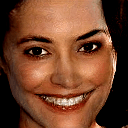

In [ ]:
def interpolate_between_vectors():
  v1 = tf.random.normal([latent_dim])
  v2 = tf.random.normal([latent_dim])

  # create a tensor with 25 steps of interpolation between v1 and v2.
  vectors = interpolate_hypersphere(v1 , v2 , 50)

  # uses module to generate images from the latent space
  interpolated_images = progan(vectors)['default']

  return interpolated_images
interpolated_images = interpolate_between_vectors()
animate(interpolated_images)


# Finding the closest vector in latent space
Fix a target image. As an example use an image generated from the module or upload your own

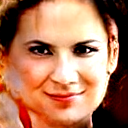

In [ ]:
image_from_module_space = True

def get_module_space_image():
  vector = tf.random.normal([1 , latent_dim])
  images = progan(vector)['default'][0]
  return images

def upload_image():
  uploaded = files.upload()
  image = imageio.imread(uploaded[list(uploaded.keys())[0]])
  return transform.resize(image, [128 , 128])

if image_from_module_space:
  target_image = get_module_space_image()
else:
  target_image = upload_image()

display_image(target_image)







After defining a loss function between the target image and the image generated by a latent space variable, we can use gradient descent to find the variable values that minimize the loss.

In [ ]:
tf.random.set_seed(42)
initial_vector = tf.random.normal([1 , latent_dim])


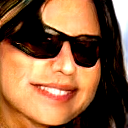

In [ ]:
display_image(progan(initial_vector)['default'][0])

In [ ]:
def find_closest_latent_vector(initial_vector , num_optimization_steps,
                               steps_per_image):
  images = []
  losses = []

  vector = tf.Variable(initial_vector)
  optimizer = tf.optimizers.Adam(learning_rate = 0.01)
  loss_fn = tf.losses.MeanAbsoluteError(reduction = "sum")

  for step in range(num_optimization_steps):
    if (step % 100) == 0:
      print()
    print('.' , end = '')
    with tf.GradientTape() as tape:
      image = progan(vector.read_value())['default'][0]
      if (step % steps_per_image) == 0:
        images.append(image.numpy())
      target_image_difference = loss_fn(image , target_image[: , : , :3])
      # The latent vectors were sampled from a normal distribution. We can get
      # more realistic images if we regularize the length of the latent vector to
      # the average length of vector from this distribution.

      regularizer = tf.abs(tf.norm(vector) - np.sqrt(latent_dim))

      loss = target_image_difference + regularizer
      losses.append(loss.numpy())

    grads = tape.gradient(loss , [vector])
    optimizer.apply_gradients(zip(grads , [vector]))

  return images , losses

num_optimization_steps = 200
steps_per_image = 5
images , loss = find_closest_latent_vector(initial_vector , num_optimization_steps, steps_per_image)


....................................................................................................
....................................................................................................

(0.0, 5312.597348022461)

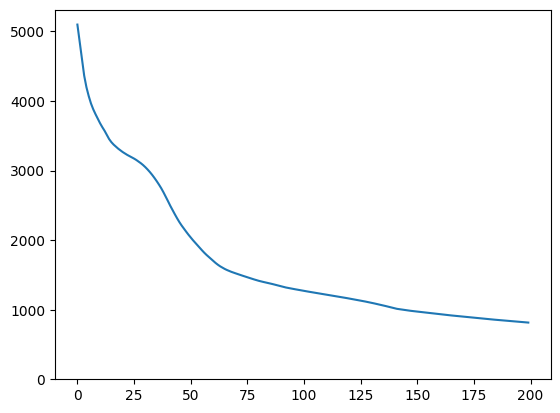

In [ ]:
plt.plot(loss)
plt.ylim([0 , max(plt.ylim())])

compare the result to the target

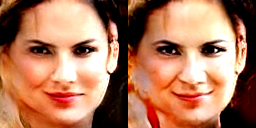

In [ ]:
display_image(np.concatenate([images[-1] , target_image], axis = 1))


# Playing with the above example

If image is from the module space, the descent is quick and converges to a reasonable sample. Try out descending to an image that is not from the module space. The descent will only converge if the image is reasonably close to the space of training images.

How to make it descend faster and to a more realistic image? One can try:

- using different loss on the image difference, e.g., quadratic,
- using different regularizer on the latent vector,
- initializing from a random vector in multiple runs,etc.

